In [1]:
pip install pandas matplotlib scikit-learn scipy numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

ev_sales      = pd.read_csv(r'C:\Users\Atharva\Desktop\Data Analysis Project 3\electric-car-sales.csv')
ev_share      = pd.read_csv(r'C:\Users\Atharva\Desktop\Data Analysis Project 3\electric-car-sales-share.csv')
battery       = pd.read_csv(r'C:\Users\Atharva\Desktop\Data Analysis Project 3\price-of-lithium-ion-battery-cells.csv')
charging      = pd.read_csv(r'C:\Users\Atharva\Desktop\Data Analysis Project 3\ev_charging_infrastructure.csv')
manufacturers = pd.read_csv(r'C:\Users\Atharva\Desktop\Data Analysis Project 3\ev_manufacturer_market_share.csv')

ev_sales.rename(columns={'Entity': 'country', 'Year': 'year', 'Electric cars sold': 'ev_sales'}, inplace=True)
ev_share.rename(columns={'Entity': 'country', 'Year': 'year', 'Share of new cars that are electric': 'market_share_pct'}, inplace=True)
battery.rename(columns={'Entity': 'country', 'Year': 'year', 'Price of lithium-ion battery cells': 'battery_price_usd'}, inplace=True)

focus_countries = [
    'China', 'United States', 'Germany', 'United Kingdom', 'France', 'Norway', 'Netherlands', 'Canada', 'Japan', 'South Korea'
]
ev_sales = ev_sales[ev_sales['country'].isin(focus_countries)]
ev_share = ev_share[ev_share['country'].isin(focus_countries)]
print("✅ All datasets loaded successfully")
print(f"   ev_sales:      {ev_sales.shape}")
print(f"   ev_share:      {ev_share.shape}")
print(f"   battery:       {battery.shape}")
print(f"   charging:      {charging.shape}")
print(f"   manufacturers: {manufacturers.shape}")


✅ All datasets loaded successfully
   ev_sales:      (159, 4)
   ev_share:      (159, 4)
   battery:       (34, 4)
   charging:      (110, 6)
   manufacturers: (96, 7)


R² = 0.040
Correlation coefficient (r) = -0.199


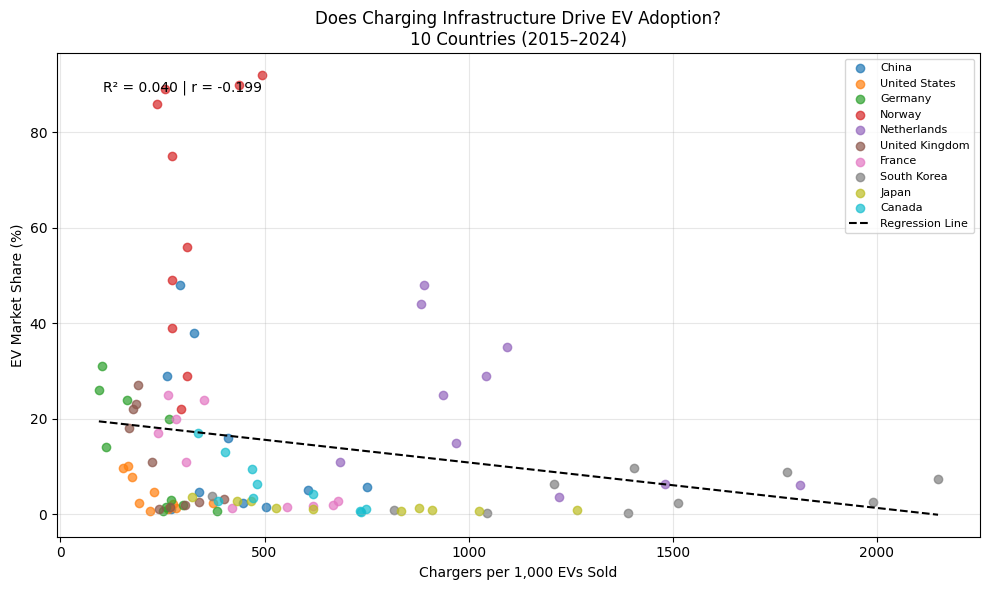

✅ Chart 1 saved


In [6]:
# CHART 1: Does Charging Infrastructure Drive EV Adoption?
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Merge charging data with EV market share
df_corr = pd.merge(
    charging,
    ev_share[['country', 'year', 'market_share_pct']],
    on=['country', 'year']
)

# Merge with EV sales to calculate charger density
df_corr = pd.merge(
    df_corr,
    ev_sales[['country', 'year', 'ev_sales']],
    on=['country', 'year']
)

# Calculate chargers per 1000 EVs sold
df_corr['chargers_per_1000_evs'] = (
    df_corr['total_public_chargers']
    / df_corr['ev_sales'] * 1000
).round(1)

# Filter to 2015-2024 and drop missing values
df_corr = df_corr[
    (df_corr['year'] >= 2015) &
    (df_corr['year'] <= 2024)
].dropna()

# Run linear regression
x = df_corr['chargers_per_1000_evs']
y = df_corr['market_share_pct']

slope, intercept, r_value, _, _ = stats.linregress(x, y)
r_squared = r_value ** 2

print(f"R² = {r_squared:.3f}")
print(f"Correlation coefficient (r) = {r_value:.3f}")

# Plot scatter — one colour per country, auto-assigned by matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

for country in df_corr['country'].unique():
    subset = df_corr[df_corr['country'] == country]
    ax.scatter(
        subset['chargers_per_1000_evs'],
        subset['market_share_pct'],
        label=country,
        alpha=0.7
    )

# Regression line — black dashed so it stands out from country dots
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(
    x_line, y_line,
    color='black',       # FIX 1: makes regression line clearly visible
    linestyle='--',
    linewidth=1.5,
    label='Regression Line'
)

# Add R² text on chart
ax.text(
    0.05, 0.92,
    f'R² = {r_squared:.3f} | r = {r_value:.3f}',
    transform=ax.transAxes,
    fontsize=10           # FIX 2: readable size
)

# Axis labels and title
ax.set_xlabel('Chargers per 1,000 EVs Sold')
ax.set_ylabel('EV Market Share (%)')
ax.set_title(
    'Does Charging Infrastructure Drive EV Adoption?\n'
    '10 Countries (2015–2024)'
)

ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# FIX 3: Save chart to project folder
plt.savefig(
    r'C:\Users\Atharva\Desktop\Data Analysis Project 3\chart1_charger_vs_adoption.png',
    dpi=150, bbox_inches='tight'
)

plt.show()
print("✅ Chart 1 saved")

Global sales rows found: 10
   year  ev_sales
0  2015    520000
1  2016    780000
2  2017   1200000
3  2018   2050000
4  2019   2080000
5  2020   2980000
6  2021   6600000
7  2022  10200000
8  2023  13700000
9  2024  17500000


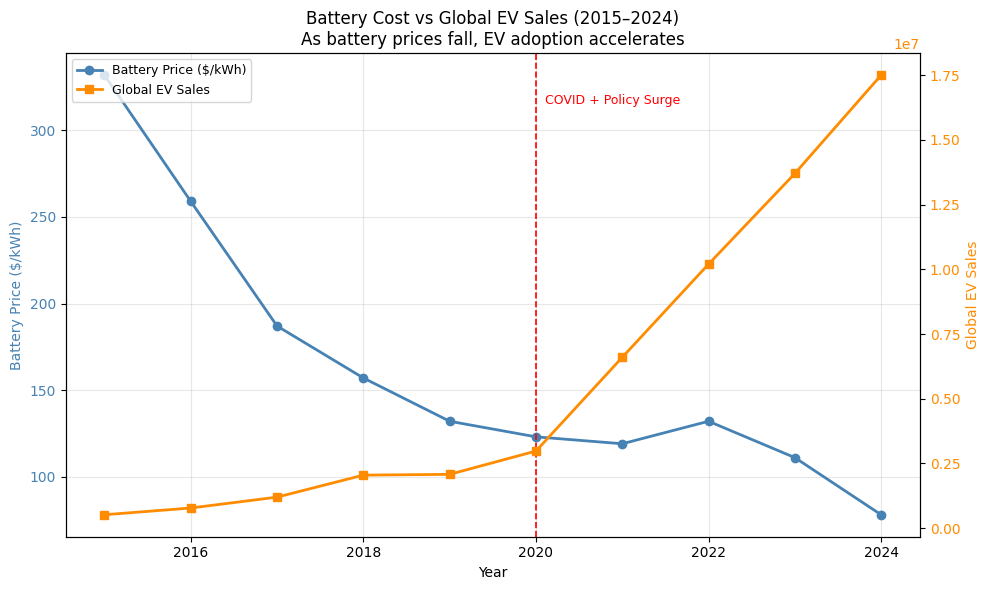

✅ Chart 2 saved


In [10]:
# Chart 2: Battery Cost vs Global EV Sales (2015-2024)

import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare battery cost data ---
battery_filtered = battery[
    (battery['year'] >= 2015) &
    (battery['year'] <= 2024)
].copy()

# --- Prepare global EV sales ---
# Load raw file again to get World total (was filtered out in setup)
ev_sales_raw = pd.read_csv(r'C:\Users\Atharva\Desktop\Data Analysis Project 3\electric-car-sales.csv')
ev_sales_raw.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Electric cars sold': 'ev_sales'
}, inplace=True)

global_sales = ev_sales_raw[
    (ev_sales_raw['country'] == 'World') &
    (ev_sales_raw['year'] >= 2015) &
    (ev_sales_raw['year'] <= 2024)
].groupby('year')['ev_sales'].sum().reset_index()

print("Global sales rows found:", len(global_sales))
print(global_sales)

# --- Create dual axis chart ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis — battery price
ax1.set_xlabel('Year')
ax1.set_ylabel('Battery Price ($/kWh)', color='steelblue')
ax1.plot(
    battery_filtered['year'],
    battery_filtered['battery_price_usd'],
    color='steelblue',
    linewidth=2,
    marker='o',
    label='Battery Price ($/kWh)'
)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Right axis — global EV sales
ax2 = ax1.twinx()
ax2.set_ylabel('Global EV Sales', color='darkorange')
ax2.plot(
    global_sales['year'],
    global_sales['ev_sales'],
    color='darkorange',
    linewidth=2,
    marker='s',
    label='Global EV Sales'
)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Vertical line at 2020
ax1.axvline(x=2020, color='red', linestyle='--', linewidth=1.2)
ax1.text(
    2020.1,
    battery_filtered['battery_price_usd'].max() * 0.95,
    'COVID + Policy Surge',
    color='red',
    fontsize=9
)

# Title and legend
plt.title(
    'Battery Cost vs Global EV Sales (2015–2024)\n'
    'As battery prices fall, EV adoption accelerates'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    r'C:\Users\Atharva\Desktop\Data Analysis Project 3\chart2_battery_vs_sales.png',
    dpi=150, bbox_inches='tight'
)

plt.show()
print("✅ Chart 2 saved")

In [12]:
# Run this in a new cell to diagnose
print(ev_sales['country'].unique())

<StringArray>
[        'Canada',          'China',         'France',        'Germany',
          'Japan',    'Netherlands',         'Norway',    'South Korea',
 'United Kingdom',  'United States']
Length: 10, dtype: str


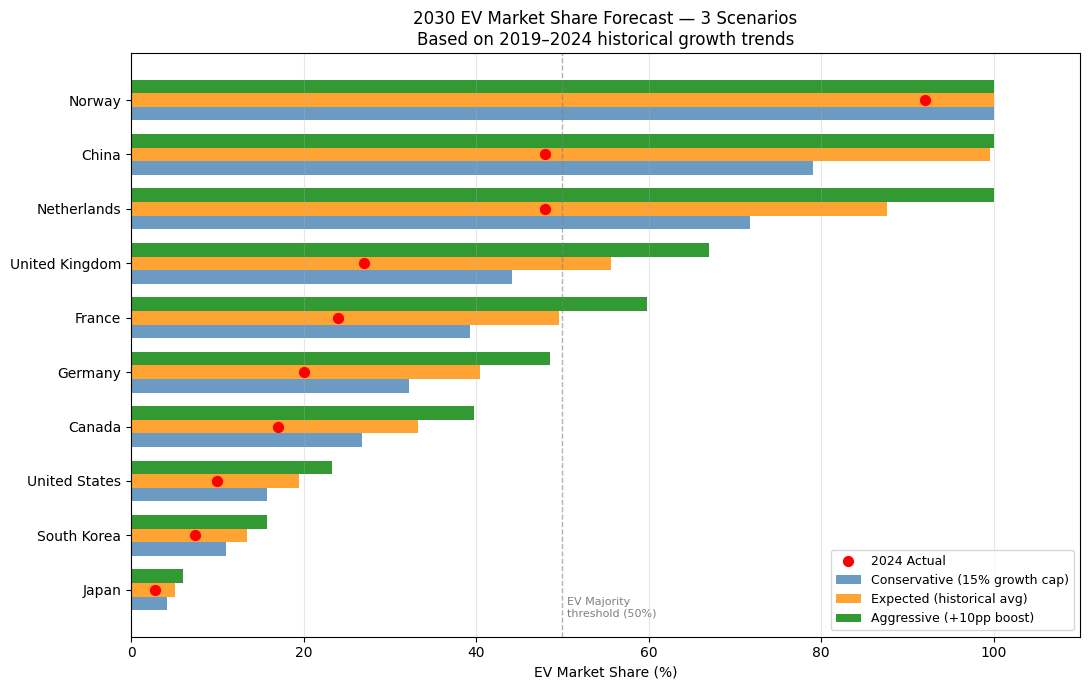

✅ Chart 3 saved


In [14]:
# Chart 3: 2030 EV Market Share Forecast — 3 Scenarios
# Shows where each country is headed under conservative, expected, aggressive assumptions

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Forecast data from Query 4 results ---
# Manually entered from our BigQuery Query 4 output
forecast_data = {
    'country':               ['Norway', 'China', 'Netherlands', 'United Kingdom',
                              'France', 'Germany', 'Canada', 'United States',
                              'South Korea', 'Japan'],
    'market_share_2024':     [92.0, 48.0, 48.0, 27.0, 24.0, 20.0, 17.0, 10.0, 7.4, 2.8],
    'share_2030_conservative':[100.0, 79.0, 71.8, 44.1, 39.3, 32.2, 26.8, 15.7, 11.0, 4.2],
    'share_2030_expected':   [100.0, 99.6, 87.6, 55.6, 49.6, 40.4, 33.3, 19.5, 13.4, 5.1],
    'share_2030_aggressive': [100.0, 100.0, 100.0, 67.0, 59.8, 48.6, 39.8, 23.3, 15.8, 6.0]
}

df_forecast = pd.DataFrame(forecast_data)

# Sort by expected 2030 share for cleaner chart
df_forecast = df_forecast.sort_values('share_2030_expected', ascending=True)

# --- Plot horizontal bar chart with 3 scenarios ---
fig, ax = plt.subplots(figsize=(11, 7))

y = np.arange(len(df_forecast))
bar_height = 0.25

# Three bars per country
ax.barh(y - bar_height, df_forecast['share_2030_conservative'],
        height=bar_height, label='Conservative (15% growth cap)', color='steelblue', alpha=0.8)

ax.barh(y, df_forecast['share_2030_expected'],
        height=bar_height, label='Expected (historical avg)', color='darkorange', alpha=0.8)

ax.barh(y + bar_height, df_forecast['share_2030_aggressive'],
        height=bar_height, label='Aggressive (+10pp boost)', color='green', alpha=0.8)

# Add 2024 actual as a reference dot
ax.scatter(
    df_forecast['market_share_2024'],
    y,
    color='red', zorder=5, label='2024 Actual', s=50
)

# Axis labels
ax.set_xlabel('EV Market Share (%)')
ax.set_title(
    '2030 EV Market Share Forecast — 3 Scenarios\n'
    'Based on 2019–2024 historical growth trends'
)
ax.set_yticks(y)
ax.set_yticklabels(df_forecast['country'])
ax.set_xlim(0, 110)

# Add 50% reference line
ax.axvline(x=50, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.text(50.5, -0.5, 'EV Majority\nthreshold (50%)', fontsize=8, color='grey')

ax.legend(fontsize=9, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    r'C:\Users\Atharva\Desktop\Data Analysis Project 3\chart3_2030_forecast.png',
    dpi=150, bbox_inches='tight'
)

plt.show()
print("✅ Chart 3 saved")